In [1]:
# =============================================================================
# Cell 1: Library Imports and Reproducibility Configuration
# =============================================================================
# This cell loads all required libraries and establishes reproducibility via
# BASE_SEED. BLAS threading is reduced to minimize nondeterminism.

import os
import sys
import pickle
from time import time
from datetime import datetime
from typing import Optional, Tuple, Dict, List, Any
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

# Ray for parallel execution (optional - graceful fallback if unavailable)
try:
    import ray
    RAY_AVAILABLE = True
except ImportError:
    RAY_AVAILABLE = False

# Master seed for reproducibility across all experiments
BASE_SEED = 316

# Reduce BLAS threading nondeterminism
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

# Matplotlib configuration for publication-quality figures
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "font.size": 11})

print("Strategic Bandits: Self-Play Experiments")
print("=" * 50)
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Ray: {ray.__version__ if RAY_AVAILABLE else 'Not available'}")
print(f"BASE_SEED: {BASE_SEED}")
print("Libraries loaded.")

Strategic Bandits: Self-Play Experiments
Python: 3.12.8
NumPy: 2.1.3
Ray: 2.40.0
BASE_SEED: 316
Libraries loaded.


In [2]:
# =============================================================================
# Cell 2: Game Suite Definitions
# =============================================================================
# Canonical games for self-play experiments. Each game specifies a payoff matrix
# (row-player perspective) and action labels.
#
# For SYMMETRIC games: both players use the same matrix with role-swapped lookups.
# For ASYMMETRIC games (e.g., Battle of the Sexes): payoff_matrix_p2 specifies
# the column player's payoffs separately.

GAMES: Dict[str, Dict[str, Any]] = {
    "pd": {
        "label": "Prisoner's Dilemma",
        "actions": ["C", "D"],
        "payoff_matrix": np.array([[3, 0], [5, 1]], dtype=float),
        "symmetric": True,
    },
    "stag_hunt": {
        "label": "Stag Hunt",
        "actions": ["Stag", "Hare"],
        "payoff_matrix": np.array([[5, 0], [3, 3]], dtype=float),
        "symmetric": True,
    },
    "battle_sexes": {
        "label": "Battle of the Sexes",
        "actions": ["Opera", "Football"],
        # Asymmetric: P1 prefers Opera (payoff 3), P2 prefers Football (payoff 3)
        # Coordination yields positive payoffs; miscoordination yields 0
        "payoff_matrix": np.array([[3, 0], [0, 1]], dtype=float),      # P1's payoffs
        "payoff_matrix_p2": np.array([[1, 0], [0, 3]], dtype=float),   # P2's payoffs
        "symmetric": False,
    },
    "divide_cake": {
        "label": "Divide the Cake",
        "actions": ["1/3", "1/2", "2/3"],
        "payoff_matrix": np.array([[1/3, 1/3, 1/3], [1/2, 1/2, 0.0], [2/3, 0.0, 0.0]], dtype=float),
        "symmetric": True,
    },
    "centipede": {
        "label": "Quasi-Centipede",
        "actions": ["Stop@0", "Stop@1", "Continue"],
        "payoff_matrix": np.array([[2, 5, 5], [1, 4, 7], [1, 3, 6]], dtype=float),
        "symmetric": True,
    },
}

print("Game Suite:")
for k, v in GAMES.items():
    M = v["payoff_matrix"]
    sym = "symmetric" if v.get("symmetric", True) else "ASYMMETRIC"
    print(f"  {k}: {v['label']} | {M.shape[0]}x{M.shape[1]} | [{M.min():.2f}, {M.max():.2f}] | {sym}")

Game Suite:
  pd: Prisoner's Dilemma | 2x2 | [0.00, 5.00] | symmetric
  stag_hunt: Stag Hunt | 2x2 | [0.00, 5.00] | symmetric
  battle_sexes: Battle of the Sexes | 2x2 | [0.00, 3.00] | ASYMMETRIC
  divide_cake: Divide the Cake | 3x3 | [0.00, 0.67] | symmetric
  centipede: Quasi-Centipede | 3x3 | [1.00, 7.00] | symmetric


In [3]:
# =============================================================================
# Cell 3: Epsilon-Greedy Policy
# =============================================================================
# Standard epsilon-greedy bandit algorithm with decaying exploration.

@dataclass
class EpsilonGreedyPolicy:
    """Epsilon-greedy action-value learner with 1/t decay."""
    arms: int
    rng: np.random.Generator
    q: np.ndarray = None
    n: np.ndarray = None

    def __init__(self, arms: int, rng: np.random.Generator):
        self.arms = arms
        self.rng = rng
        self.q = np.zeros(arms, dtype=float)
        self.n = np.zeros(arms, dtype=int)

    def reset(self) -> None:
        """Reset Q-values and counts."""
        self.q.fill(0.0)
        self.n.fill(0)

    def select_action(self, epsilon: float) -> int:
        """Select action using epsilon-greedy with random tie-breaking."""
        if self.rng.random() > epsilon:
            best = np.flatnonzero(self.q == np.max(self.q))
            return int(self.rng.choice(best))
        return int(self.rng.integers(self.arms))

    def update(self, action: int, reward: float) -> None:
        """Update Q-value for the selected action."""
        self.n[action] += 1
        self.q[action] += (reward - self.q[action]) / self.n[action]

print("EpsilonGreedyPolicy defined.")

EpsilonGreedyPolicy defined.


In [4]:
# =============================================================================
# Cell 4: Thompson Sampling Policy (Gaussian)
# =============================================================================
# Gaussian Thompson Sampling with Normal-Normal conjugate updates.

@dataclass
class GaussianThompsonSampling:
    """Gaussian Thompson Sampling for real-valued rewards."""
    arms: int
    rng: np.random.Generator
    prior_mean: float = 0.0
    prior_var: float = 100.0
    reward_var: float = 1.0
    post_mean: np.ndarray = None
    post_var: np.ndarray = None

    def __init__(self, arms: int, rng: np.random.Generator, reward_std: Optional[float] = None,
                 payoff_matrix: Optional[np.ndarray] = None, prior_mean: float = 0.0, prior_std: float = 10.0):
        self.arms = arms
        self.rng = rng
        self.prior_mean = prior_mean
        self.prior_var = prior_std ** 2
        if reward_std is None:
            reward_std = float(np.std(payoff_matrix)) if payoff_matrix is not None else 1.0
            if reward_std == 0.0: reward_std = 1.0
        self.reward_var = reward_std ** 2
        self.post_mean = np.full(arms, self.prior_mean)
        self.post_var = np.full(arms, self.prior_var)

    def reset(self) -> None:
        """Reset posteriors to priors."""
        self.post_mean.fill(self.prior_mean)
        self.post_var.fill(self.prior_var)

    def select_action(self) -> int:
        """Sample from posteriors and select the arm with highest sample."""
        samples = self.rng.normal(self.post_mean, np.sqrt(self.post_var))
        return int(np.argmax(samples))

    def update(self, action: int, reward: float) -> None:
        """Update posterior using conjugate Normal-Normal update."""
        prior_prec = 1.0 / self.post_var[action]
        like_prec = 1.0 / self.reward_var
        post_prec = prior_prec + like_prec
        self.post_var[action] = 1.0 / post_prec
        self.post_mean[action] = self.post_var[action] * (prior_prec * self.post_mean[action] + like_prec * reward)

print("GaussianThompsonSampling defined.")

GaussianThompsonSampling defined.


In [5]:
# =============================================================================
# Cell 5: Exp3 Policy
# =============================================================================
# Exp3 algorithm for adversarial bandits with importance-weighted updates.
# Rewards MUST be normalized to [0,1] before calling update().

@dataclass
class Exp3Policy:
    """Exp3 algorithm for adversarial bandits."""
    arms: int
    rng: np.random.Generator
    gamma: float = 0.1
    weights: np.ndarray = None
    last_probs: np.ndarray = None

    def __init__(self, arms: int, rng: np.random.Generator, gamma: Optional[float] = None, time_horizon: Optional[int] = None):
        self.arms = arms
        self.rng = rng
        if gamma is not None:
            self.gamma = gamma
        elif time_horizon is not None:
            self.gamma = np.sqrt(arms * np.log(arms) / ((np.e - 1) * time_horizon))
        else:
            self.gamma = np.sqrt(arms * np.log(arms) / ((np.e - 1) * 5000))
        self.gamma = float(np.clip(self.gamma, 0.01, 1.0))
        self.weights = np.ones(arms)
        self.last_probs = None

    def reset(self) -> None:
        """Reset weights to uniform."""
        self.weights.fill(1.0)
        self.last_probs = None

    def select_action(self) -> int:
        """Select action using mixed exploration-exploitation probabilities."""
        w_sum = np.sum(self.weights)
        p = (1 - self.gamma) * (self.weights / w_sum) + self.gamma / self.arms
        self.last_probs = p / p.sum()
        return int(self.rng.choice(self.arms, p=self.last_probs))

    @staticmethod
    def normalize_reward(reward: float, r_min: float, r_max: float) -> float:
        """Map reward to [0,1] for theoretical correctness."""
        if r_max <= r_min:
            return 0.5
        return float(np.clip((reward - r_min) / (r_max - r_min), 0.0, 1.0))

    def update(self, action: int, reward_01: float) -> None:
        """Update weights using importance-weighted reward estimate."""
        x_hat = reward_01 / self.last_probs[action]
        self.weights[action] *= np.exp(self.gamma * x_hat / self.arms)

print("Exp3Policy defined.")

Exp3Policy defined.


In [6]:
# =============================================================================
# Cell 6: Policy Factory
# =============================================================================
# Creates policy instances with consistent hyperparameters across experiments.

def make_policy(policy_type: str, n_actions: int, rng: np.random.Generator,
                payoff_matrix: np.ndarray, time_horizon: int,
                prior_mean: float = 0.0, prior_std: float = 10.0) -> Any:
    """
    Factory function to create learning policy instances.
    
    Args:
        policy_type: One of 'epsilon_greedy', 'thompson', 'exp3'
        n_actions: Number of available actions
        rng: NumPy random generator for this policy
        payoff_matrix: Game payoff matrix (used to infer reward variance)
        time_horizon: Total timesteps (used for Exp3 gamma calculation)
        prior_mean: Thompson Sampling prior mean
        prior_std: Thompson Sampling prior standard deviation
    
    Returns:
        Policy instance with select_action(), update(), reset() methods.
    """
    policy_type = policy_type.lower()
    if policy_type == "epsilon_greedy":
        return EpsilonGreedyPolicy(n_actions, rng)
    elif policy_type == "thompson":
        return GaussianThompsonSampling(n_actions, rng, payoff_matrix=payoff_matrix,
                                        prior_mean=prior_mean, prior_std=prior_std)
    elif policy_type == "exp3":
        return Exp3Policy(n_actions, rng, time_horizon=time_horizon)
    else:
        raise ValueError(f"Unknown policy type: {policy_type}")

print("Policy factory defined.")

Policy factory defined.


In [7]:
# =============================================================================
# Cell 7: Self-Play Episode Runner
# =============================================================================
# Runs a single self-play episode with two independent learners of the same
# policy class. Supports both symmetric and asymmetric games.
#
# SYMMETRIC games: P1 gets M[a1,a2], P2 gets M[a2,a1] (role-swapped)
# ASYMMETRIC games: P1 gets M1[a1,a2], P2 gets M2[a1,a2] (separate matrices)

def run_self_play_episode(payoff_matrix_p1: np.ndarray, payoff_matrix_p2: np.ndarray,
                          policy_type: str, time_steps: int, rng: np.random.Generator,
                          prior_mean: float = 0.0, prior_std: float = 10.0) -> Dict[str, np.ndarray]:
    """
    Run one self-play episode with two independent learners.
    
    Args:
        payoff_matrix_p1: P1's payoff matrix (row=P1 action, col=P2 action)
        payoff_matrix_p2: P2's payoff matrix (row=P1 action, col=P2 action)
        policy_type: Learning algorithm to use
        time_steps: Number of timesteps per episode
        rng: Random generator for this episode
        prior_mean, prior_std: Thompson Sampling hyperparameters
    
    Returns:
        Dict with cumulative rewards, actions, and joint action counts.
    """
    n_actions = payoff_matrix_p1.shape[0]
    
    # Compute payoff bounds for Exp3 normalization (use combined range)
    all_payoffs = np.concatenate([payoff_matrix_p1.flatten(), payoff_matrix_p2.flatten()])
    payoff_min = float(np.min(all_payoffs))
    payoff_max = float(np.max(all_payoffs))
    
    # Create two independent RNG streams for the two players
    child_seqs = rng.bit_generator._seed_seq.spawn(2)
    rng_p1 = np.random.default_rng(child_seqs[0])
    rng_p2 = np.random.default_rng(child_seqs[1])
    
    # Create policies (P1 uses its matrix for Thompson prior estimation)
    p1 = make_policy(policy_type, n_actions, rng_p1, payoff_matrix_p1, time_steps, prior_mean, prior_std)
    p2 = make_policy(policy_type, n_actions, rng_p2, payoff_matrix_p2, time_steps, prior_mean, prior_std)
    
    # Tracking arrays
    cum_r1 = np.zeros(time_steps, dtype=float)
    cum_r2 = np.zeros(time_steps, dtype=float)
    actions_p1 = np.zeros(time_steps, dtype=int)
    actions_p2 = np.zeros(time_steps, dtype=int)
    joint_counts = np.zeros((n_actions, n_actions), dtype=int)
    
    total_r1, total_r2 = 0.0, 0.0
    
    for t in range(time_steps):
        # Action selection
        if policy_type == "epsilon_greedy":
            epsilon = 1.0 / (t + 1)
            a1 = p1.select_action(epsilon)
            a2 = p2.select_action(epsilon)
        else:
            a1 = p1.select_action()
            a2 = p2.select_action()
        
        # Payoffs from respective matrices
        r1 = float(payoff_matrix_p1[a1, a2])
        r2 = float(payoff_matrix_p2[a1, a2])
        
        # Policy updates
        if policy_type == "exp3":
            p1.update(a1, Exp3Policy.normalize_reward(r1, payoff_min, payoff_max))
            p2.update(a2, Exp3Policy.normalize_reward(r2, payoff_min, payoff_max))
        else:
            p1.update(a1, r1)
            p2.update(a2, r2)
        
        # Record
        total_r1 += r1
        total_r2 += r2
        cum_r1[t] = total_r1
        cum_r2[t] = total_r2
        actions_p1[t] = a1
        actions_p2[t] = a2
        joint_counts[a1, a2] += 1
    
    return {
        "cum_reward_p1": cum_r1,
        "cum_reward_p2": cum_r2,
        "actions_p1": actions_p1,
        "actions_p2": actions_p2,
        "joint_action_counts": joint_counts,
    }

print("Self-play episode runner defined (supports asymmetric games).")

Self-play episode runner defined (supports asymmetric games).


In [8]:
# =============================================================================
# Cell 8: Episode Aggregation Function
# =============================================================================
# Aggregates results across multiple episodes for a single (game, policy) pair.
# Uses SeedSequence.spawn() for efficient, reproducible RNG generation.

def aggregate_self_play(payoff_matrix_p1: np.ndarray, payoff_matrix_p2: np.ndarray,
                        game_key: str, policy_type: str,
                        episodes: int, time_steps: int, base_seed: int,
                        prior_mean: float = 0.0, prior_std: float = 10.0) -> Dict[str, Any]:
    """
    Run multiple self-play episodes and aggregate results.
    
    Uses SeedSequence.spawn() for efficient parallel-safe RNG generation.
    
    Returns dict with averaged trajectories and joint action frequencies.
    """
    n_actions = payoff_matrix_p1.shape[0]
    
    # Create deterministic seed from base_seed + identifiers
    game_hash = sum(ord(c) * (i + 1) for i, c in enumerate(game_key))
    policy_hash = sum(ord(c) * (i + 1) for i, c in enumerate(policy_type))
    parent_seq = np.random.SeedSequence([base_seed, game_hash, policy_hash])
    child_seqs = parent_seq.spawn(episodes)
    
    # Accumulators
    avg_cum_r1 = np.zeros(time_steps, dtype=float)
    avg_cum_r2 = np.zeros(time_steps, dtype=float)
    avg_joint = np.zeros((n_actions, n_actions), dtype=float)
    
    for ep, seq in enumerate(child_seqs):
        ep_rng = np.random.default_rng(seq)
        result = run_self_play_episode(payoff_matrix_p1, payoff_matrix_p2,
                                       policy_type, time_steps, ep_rng,
                                       prior_mean, prior_std)
        avg_cum_r1 += result["cum_reward_p1"]
        avg_cum_r2 += result["cum_reward_p2"]
        avg_joint += result["joint_action_counts"]
    
    avg_cum_r1 /= episodes
    avg_cum_r2 /= episodes
    avg_joint /= episodes
    
    # Derived metrics
    t_arr = np.arange(1, time_steps + 1)
    avg_payoff_p1 = avg_cum_r1 / t_arr
    avg_payoff_p2 = avg_cum_r2 / t_arr
    
    return {
        "game_key": game_key,
        "policy": policy_type,
        "episodes": episodes,
        "time_steps": time_steps,
        "avg_cum_reward_p1": avg_cum_r1,
        "avg_cum_reward_p2": avg_cum_r2,
        "avg_payoff_p1": avg_payoff_p1,
        "avg_payoff_p2": avg_payoff_p2,
        "avg_joint_action_counts": avg_joint,
    }

print("Aggregation function defined.")

Aggregation function defined.


In [9]:
# =============================================================================
# Cell 9: Ray Initialization
# =============================================================================
# Initialize Ray for parallel execution of experiments.

def init_ray() -> bool:
    """Initialize Ray if available. Returns True if Ray is ready."""
    if not RAY_AVAILABLE:
        print("Ray not available; experiments will run serially.")
        return False
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)
    print("Ray initialized.")
    return True

RAY_READY = init_ray()

2025-12-31 15:18:09,841	INFO worker.py:1821 -- Started a local Ray instance.


Ray initialized.


In [10]:
# =============================================================================
# Cell 10: Ray Remote Wrapper
# =============================================================================
# Ray-decorated version of the aggregation function for parallel execution.

if RAY_AVAILABLE:
    @ray.remote
    def run_self_play_remote(payoff_matrix_p1: np.ndarray, payoff_matrix_p2: np.ndarray,
                             game_key: str, policy_type: str,
                             episodes: int, time_steps: int, base_seed: int,
                             prior_mean: float, prior_std: float) -> Dict[str, Any]:
        """Ray remote wrapper for aggregate_self_play."""
        return aggregate_self_play(payoff_matrix_p1, payoff_matrix_p2, game_key, policy_type,
                                   episodes, time_steps, base_seed, prior_mean, prior_std)

print("Ray remote wrapper defined." if RAY_AVAILABLE else "Ray not available; using serial execution.")

Ray remote wrapper defined.


In [11]:
# =============================================================================
# Cell 11: Master Orchestration Function
# =============================================================================
# Runs the full self-play experimental pipeline across all games and policies.
# Returns a schema-correct results dict suitable for serialization.

def get_payoff_matrices(game_data: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract P1 and P2 payoff matrices from game definition.
    
    For symmetric games, P2's matrix is derived via role-swap transpose.
    For asymmetric games, uses the explicit payoff_matrix_p2.
    """
    M1 = game_data["payoff_matrix"]
    if game_data.get("symmetric", True):
        # Symmetric: P2 gets M[a2, a1] when actions are (a1, a2)
        # This is equivalent to P2 seeing the transpose
        M2 = M1.T
    else:
        # Asymmetric: use explicit P2 matrix
        M2 = game_data["payoff_matrix_p2"]
    return M1, M2


def run_self_play_experiments(*, episodes: int = 2000, time_steps: int = 5000,
                               policies_to_test: Tuple[str, ...] = ("epsilon_greedy", "thompson", "exp3"),
                               games_to_run: Optional[List[str]] = None,
                               base_seed: int = BASE_SEED,
                               prior_mean: float = 0.0, prior_std: float = 10.0,
                               use_ray: bool = True) -> Dict[str, Any]:
    """
    Run full self-play experimental pipeline.
    
    Args:
        episodes: Number of episodes per (game, policy) pair
        time_steps: Timesteps per episode
        policies_to_test: Tuple of policy names to evaluate
        games_to_run: List of game keys (default: all games)
        base_seed: Master seed for reproducibility
        prior_mean: Thompson Sampling prior mean
        prior_std: Thompson Sampling prior std
        use_ray: Whether to use Ray parallelization
    
    Returns:
        Dict with keys: meta, games (containing per-game, per-policy results)
    """
    games_to_run = list(GAMES.keys()) if games_to_run is None else games_to_run
    
    print(f"\n{'='*70}\nSELF-PLAY EXPERIMENTS\n{'='*70}")
    print(f"Games: {games_to_run}")
    print(f"Policies: {policies_to_test}")
    print(f"Episodes: {episodes}, Timesteps: {time_steps}")
    
    results = {
        "meta": {
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "base_seed": base_seed,
            "episodes": episodes,
            "time_steps": time_steps,
            "policies": policies_to_test,
            "games": games_to_run,
            "prior_mean": prior_mean,
            "prior_std": prior_std,
        },
        "games": {},
    }
    
    do_ray = use_ray and RAY_READY and RAY_AVAILABLE
    start_time = time()
    
    if do_ray:
        # Parallel execution
        tasks = []
        for gk in games_to_run:
            gdata = GAMES[gk]
            M1, M2 = get_payoff_matrices(gdata)
            results["games"][gk] = {
                "label": gdata["label"],
                "actions": gdata["actions"],
                "payoff_matrix": M1,
                "payoff_matrix_p2": M2,
                "symmetric": gdata.get("symmetric", True),
                "n_actions": M1.shape[0],
                "policies": {},
            }
            for pk in policies_to_test:
                task = run_self_play_remote.remote(M1, M2, gk, pk, episodes, time_steps,
                                                   base_seed, prior_mean, prior_std)
                tasks.append((gk, pk, task))
        
        for gk, pk, task in tasks:
            results["games"][gk]["policies"][pk] = ray.get(task)
            print(f"  ✓ {gk} | {pk}")
    else:
        # Serial execution
        for gk in games_to_run:
            gdata = GAMES[gk]
            M1, M2 = get_payoff_matrices(gdata)
            results["games"][gk] = {
                "label": gdata["label"],
                "actions": gdata["actions"],
                "payoff_matrix": M1,
                "payoff_matrix_p2": M2,
                "symmetric": gdata.get("symmetric", True),
                "n_actions": M1.shape[0],
                "policies": {},
            }
            for pk in policies_to_test:
                results["games"][gk]["policies"][pk] = aggregate_self_play(
                    M1, M2, gk, pk, episodes, time_steps, base_seed, prior_mean, prior_std)
                print(f"  ✓ {gk} | {pk}")
    
    elapsed = (time() - start_time) / 60.0
    print(f"\nTotal time: {elapsed:.2f} min")
    
    return results

print("Orchestration function defined.")

Orchestration function defined.


In [12]:
# =============================================================================
# Cell 12: Visualization Class
# =============================================================================
# Provides plotting methods for self-play analysis: payoff trajectories and
# joint-action heatmaps for equilibrium selection diagnostics.

class SelfPlayVisualizer:
    """Visualization suite for self-play experiments."""
    
    def __init__(self, results: Dict[str, Any]):
        self.results = results
        self.meta = results["meta"]
        self.games = results["games"]
        self.time_steps = self.meta["time_steps"]
        self.colors = {"epsilon_greedy": "C0", "thompson": "C1", "exp3": "C2"}
        self.labels = {"epsilon_greedy": "Epsilon-Greedy", "thompson": "Thompson Sampling", "exp3": "Exp3"}
    
    def plot_payoff_trajectories(self, game_key: str, save_path: str = None):
        """Plot average payoff over time for all policies in a game."""
        gdata = self.games[game_key]
        t = np.arange(1, self.time_steps + 1)
        is_symmetric = gdata.get("symmetric", True)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        for pk, pdata in gdata["policies"].items():
            axes[0].plot(t, pdata["avg_payoff_p1"], color=self.colors.get(pk), linewidth=2,
                        label=self.labels.get(pk, pk))
            axes[1].plot(t, pdata["avg_payoff_p2"], color=self.colors.get(pk), linewidth=2,
                        label=self.labels.get(pk, pk))
        
        axes[0].set_xlabel("Time step")
        axes[0].set_ylabel("Average payoff")
        axes[0].set_title(f"Player 1" + (" (prefers Opera)" if game_key == "battle_sexes" else ""))
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].set_xlabel("Time step")
        axes[1].set_ylabel("Average payoff")
        axes[1].set_title(f"Player 2" + (" (prefers Football)" if game_key == "battle_sexes" else ""))
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        fig.suptitle(f"{gdata['label']}: Self-Play Payoff Trajectories", fontsize=14)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")
        plt.show()
    
    def plot_joint_action_heatmap(self, game_key: str, policy_type: str, save_path: str = None):
        """Heatmap of joint action frequencies for equilibrium selection analysis."""
        gdata = self.games[game_key]
        pdata = gdata["policies"][policy_type]
        jac = pdata["avg_joint_action_counts"]
        actions = gdata["actions"]
        
        # Normalize to frequencies
        jac_norm = jac / jac.sum() if jac.sum() > 0 else jac
        
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(jac_norm, aspect="equal", cmap="Blues")
        fig.colorbar(im, ax=ax, label="Frequency")
        
        ax.set_xticks(range(len(actions)))
        ax.set_yticks(range(len(actions)))
        ax.set_xticklabels(actions)
        ax.set_yticklabels(actions)
        ax.set_xlabel("Player 2 Action")
        ax.set_ylabel("Player 1 Action")
        ax.set_title(f"{gdata['label']}: {self.labels.get(policy_type, policy_type)}\nJoint Action Frequencies")
        
        for i in range(len(actions)):
            for j in range(len(actions)):
                ax.text(j, i, f"{jac_norm[i, j]:.2f}", ha="center", va="center", fontsize=11)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")
        plt.show()

print("SelfPlayVisualizer defined.")

SelfPlayVisualizer defined.


In [13]:
# =============================================================================
# Cell 13: Run Full Experiment Suite
# =============================================================================
# Runs all games x all policies. This is compute-intensive (~15-30 min).
# Uncomment the line below to execute.

selfplay_results = run_self_play_experiments(episodes=2000, time_steps=5000)


SELF-PLAY EXPERIMENTS
Games: ['pd', 'stag_hunt', 'battle_sexes', 'divide_cake', 'centipede']
Policies: ('epsilon_greedy', 'thompson', 'exp3')
Episodes: 2000, Timesteps: 5000
  ✓ pd | epsilon_greedy
  ✓ pd | thompson
  ✓ pd | exp3
  ✓ stag_hunt | epsilon_greedy
  ✓ stag_hunt | thompson
  ✓ stag_hunt | exp3
  ✓ battle_sexes | epsilon_greedy
  ✓ battle_sexes | thompson
  ✓ battle_sexes | exp3
  ✓ divide_cake | epsilon_greedy
  ✓ divide_cake | thompson
  ✓ divide_cake | exp3
  ✓ centipede | epsilon_greedy
  ✓ centipede | thompson
  ✓ centipede | exp3

Total time: 8.55 min


In [14]:
# =============================================================================
# Cell 14: Run Single Game (Quick Test)
# =============================================================================
# For quick testing, run only one game with reduced episodes.

# test_results = run_self_play_experiments(
#      episodes=100, time_steps=1000,
#      games_to_run=["battle_sexes"],
#      policies_to_test=("epsilon_greedy", "thompson", "exp3")
#  )

In [15]:
# =============================================================================
# Cell 15: Save Results to Disk
# =============================================================================
# Saves results with both timestamped and stable filenames.

import os

def save_selfplay_results(results: Dict[str, Any], out_dir: str = "results_artifacts") -> Tuple[str, str]:
    """
    Save self-play results to pickle files.
    
    Returns paths to (versioned_file, latest_file).
    """
    os.makedirs(out_dir, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    versioned = os.path.join(out_dir, f"selfplay_results_{stamp}.pkl")
    latest = os.path.join(out_dir, "selfplay_results_latest.pkl")
    
    with open(versioned, "wb") as f:
        pickle.dump(results, f)
    with open(latest, "wb") as f:
        pickle.dump(results, f)
    
    print(f"Saved: {versioned}")
    print(f"Saved: {latest}")
    return versioned, latest

# Example usage (uncomment after running experiments):
versioned_path, latest_path = save_selfplay_results(selfplay_results)

Saved: results_artifacts/selfplay_results_20251231_152643.pkl
Saved: results_artifacts/selfplay_results_latest.pkl


In [16]:
# =============================================================================
# Cell 16: Verify Saved Data
# =============================================================================
# Loads saved results and performs integrity checks.

def verify_selfplay_results(path: str) -> bool:
    """
    Load and verify integrity of saved self-play results.
    
    Checks: required keys, array shapes, NaN/Inf values, total counts.
    """
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    ok = True
    
    if "meta" not in data or "games" not in data:
        print("❌ Missing top-level keys (meta, games)")
        return False
    
    T = data["meta"]["time_steps"]
    
    for gk, gdata in data["games"].items():
        n_actions = gdata["n_actions"]
        
        for pk, pdata in gdata["policies"].items():
            # Check required keys
            for key in ["avg_cum_reward_p1", "avg_payoff_p1", "avg_joint_action_counts"]:
                if key not in pdata:
                    print(f"❌ Missing {gk}/{pk}/{key}")
                    ok = False
            
            # Check shapes
            if pdata["avg_cum_reward_p1"].shape != (T,):
                print(f"❌ Shape mismatch {gk}/{pk}/avg_cum_reward_p1")
                ok = False
            if pdata["avg_joint_action_counts"].shape != (n_actions, n_actions):
                print(f"❌ Shape mismatch {gk}/{pk}/avg_joint_action_counts")
                ok = False
            
            # Check for NaN/Inf
            for arr_key in ["avg_cum_reward_p1", "avg_payoff_p1"]:
                arr = pdata[arr_key]
                if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
                    print(f"⚠ NaN/Inf in {gk}/{pk}/{arr_key}")
                    ok = False
            
            # Check joint counts sum to T
            jac_sum = pdata["avg_joint_action_counts"].sum()
            if not np.isclose(jac_sum, T, rtol=0.01):
                print(f"⚠ Joint counts sum to {jac_sum}, expected {T} ({gk}/{pk})")
    
    print("✓ Verification passed." if ok else "⚠ Verification failed.")
    return ok

# Example usage:
verify_selfplay_results("results_artifacts/selfplay_results_latest.pkl")

✓ Verification passed.


True

Saved: BoS_selfplay_payoffs.png


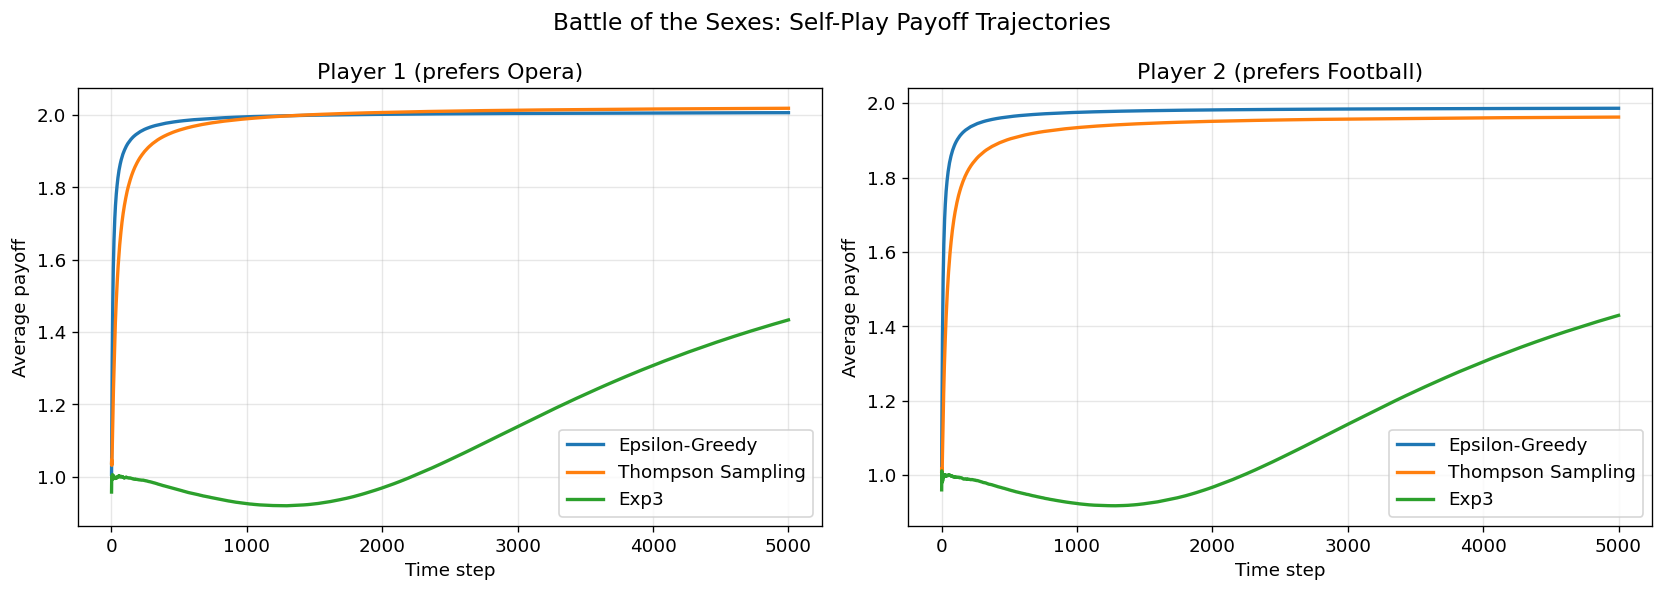

Saved: BoS_selfplay_heatmap.png


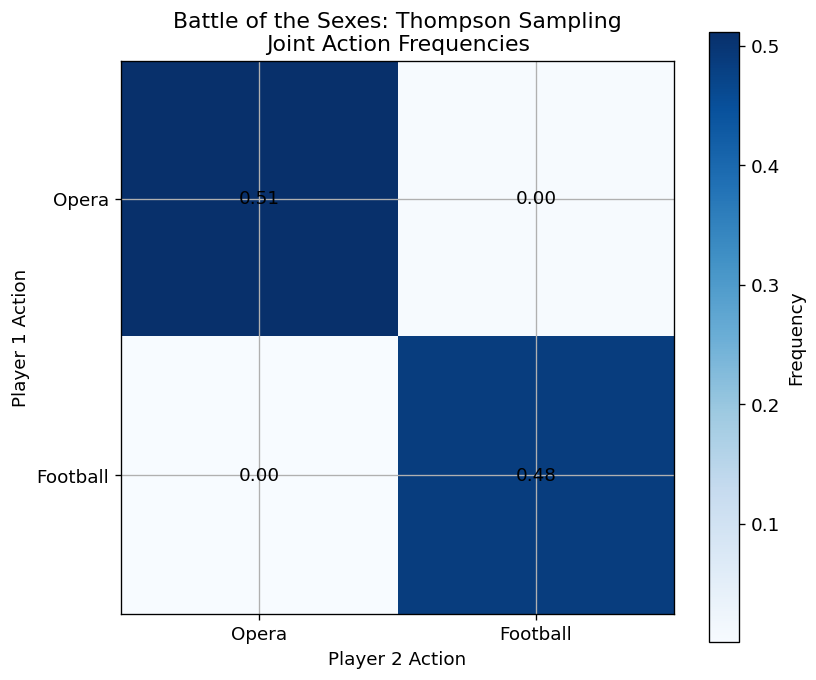

Saved: PD_selfplay_payoffs.png


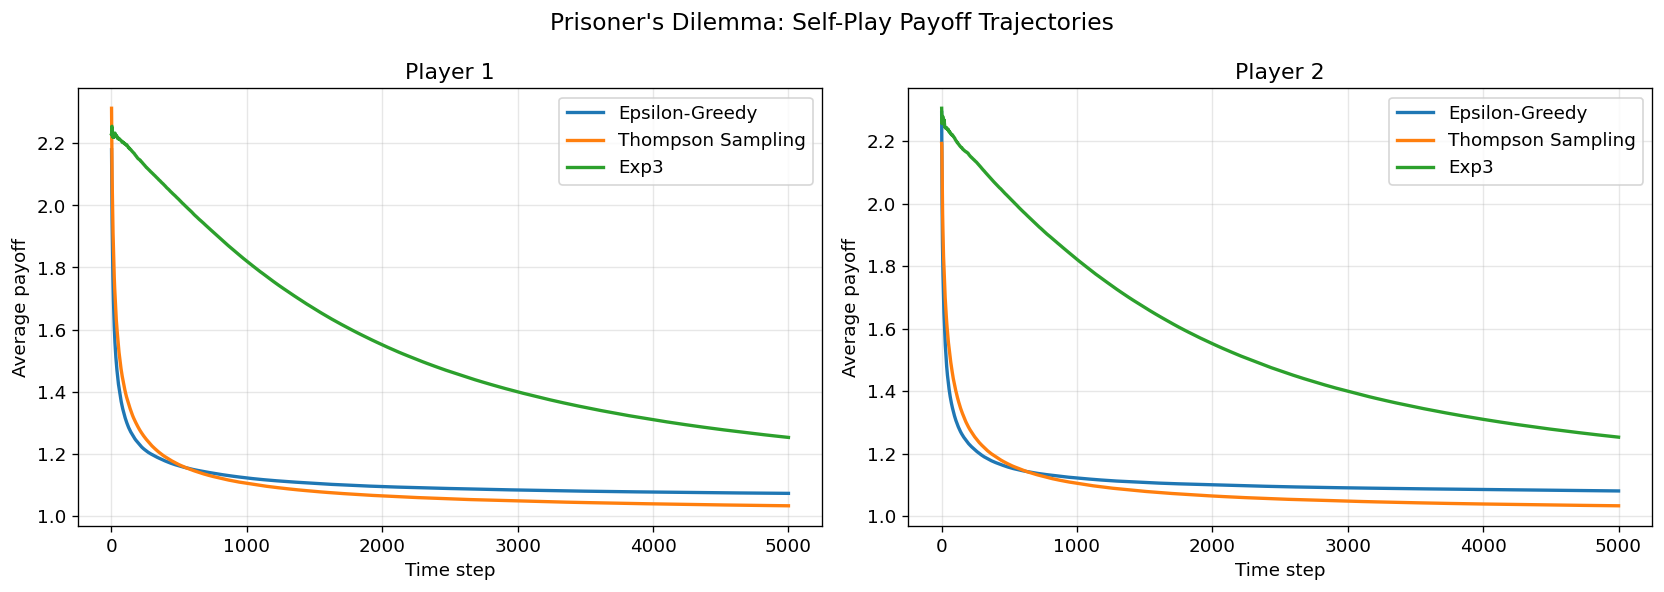

Saved: PD_selfplay_heatmap.png


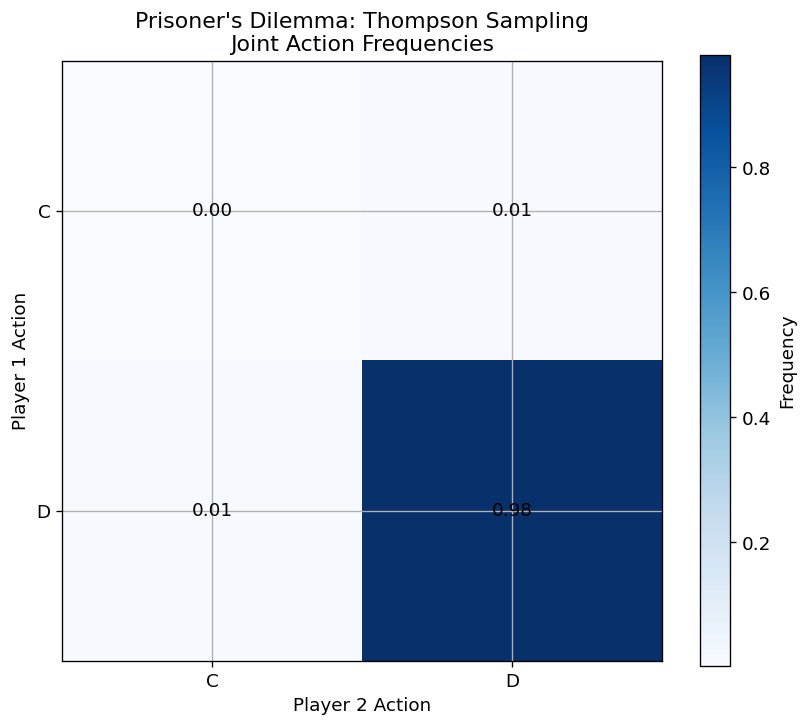

Saved: centipede_selfplay_payoffs.png


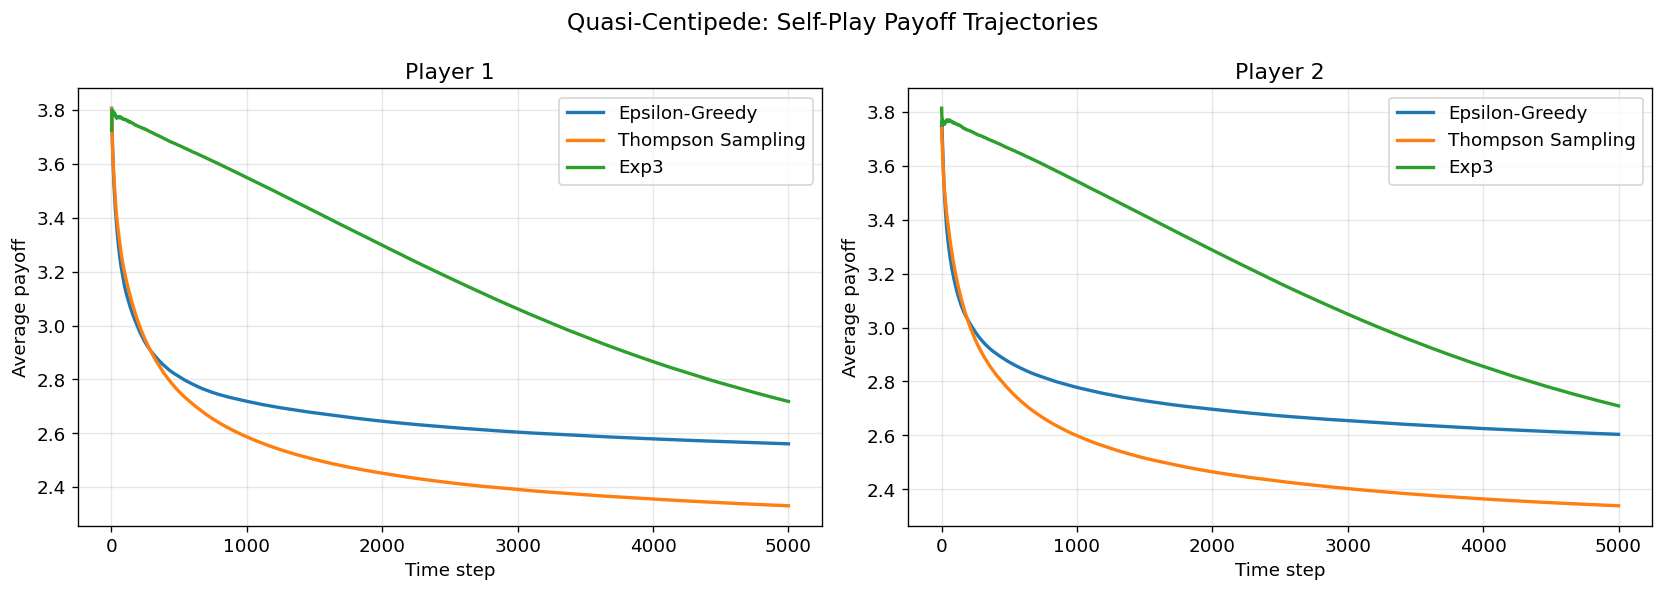

Saved: centipede_selfplay_heatmap.png


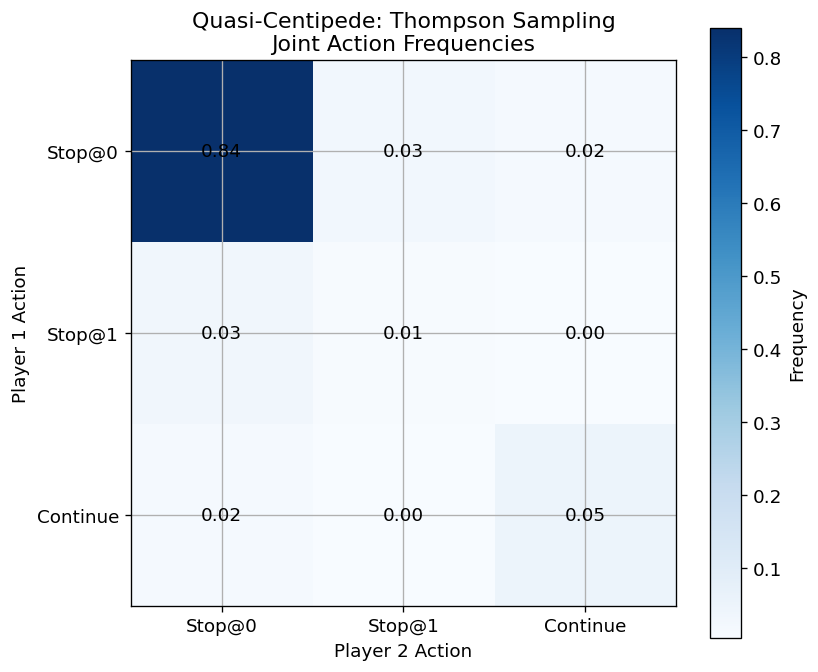

Saved: stag_hunt_selfplay_payoffs.png


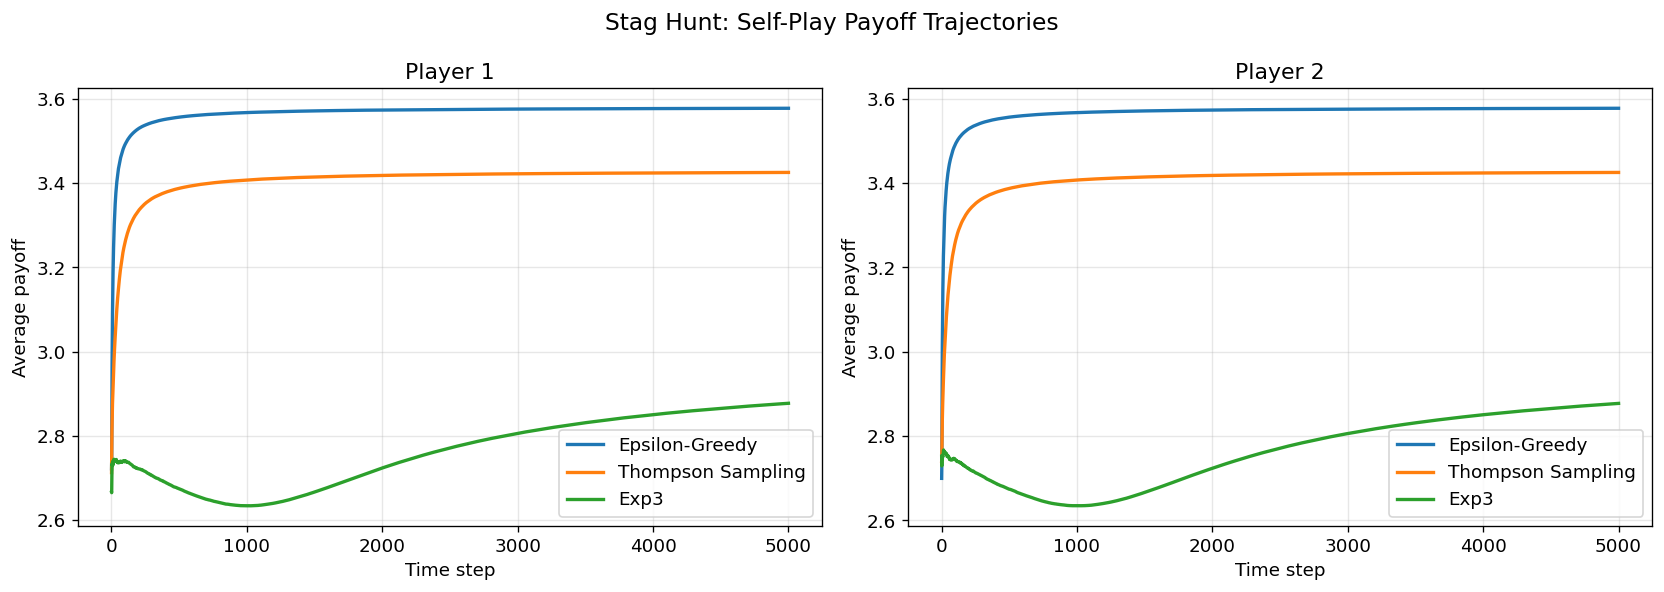

Saved: stag_hunt_selfplay_heatmap.png


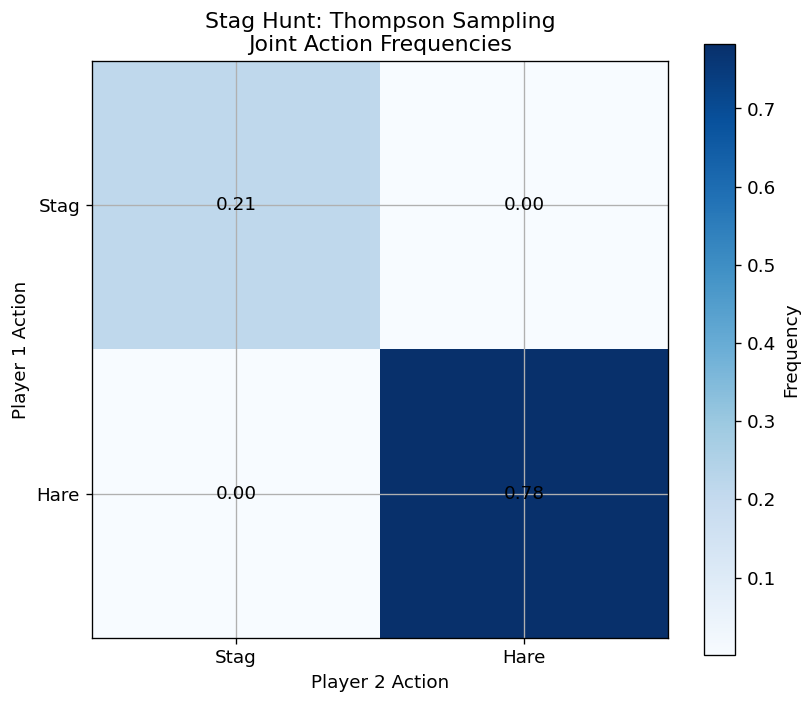

Saved: divide_cake_selfplay_payoffs.png


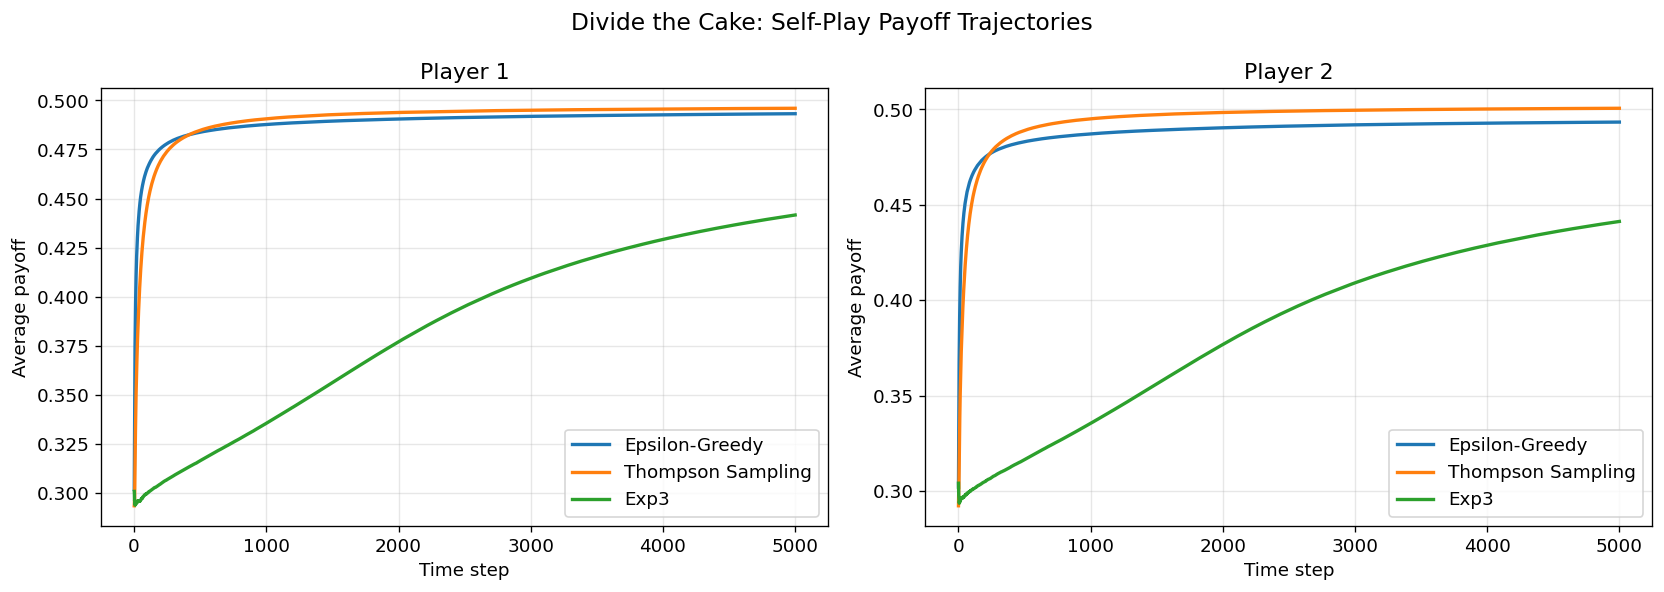

Saved: divide_cake_selfplay_heatmap.png


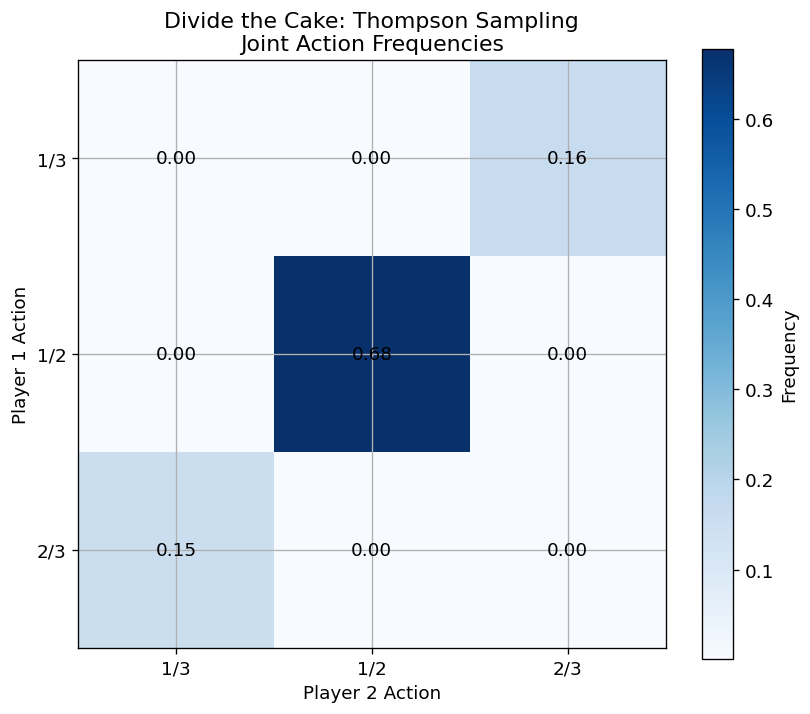

In [19]:
# =============================================================================
# Cell 17: Example Visualizations
# =============================================================================
# Demonstrates visualization after experiments are run.

viz = SelfPlayVisualizer(selfplay_results)

# Battle of the Sexes - shows asymmetric payoffs
viz.plot_payoff_trajectories("battle_sexes", save_path="BoS_selfplay_payoffs.png")
viz.plot_joint_action_heatmap("battle_sexes", "thompson", save_path="BoS_selfplay_heatmap.png")

# Prisoner's Dilemma - symmetric game
viz.plot_payoff_trajectories("pd", save_path="PD_selfplay_payoffs.png")
viz.plot_joint_action_heatmap("pd", "thompson", save_path="PD_selfplay_heatmap.png")

# Centipede Game - sequential game
viz.plot_payoff_trajectories("centipede", save_path="centipede_selfplay_payoffs.png")
viz.plot_joint_action_heatmap("centipede", "thompson", save_path="centipede_selfplay_heatmap.png")

# Stag Hunt - dominance game
viz.plot_payoff_trajectories("stag_hunt", save_path="stag_hunt_selfplay_payoffs.png")
viz.plot_joint_action_heatmap("stag_hunt", "thompson", save_path="stag_hunt_selfplay_heatmap.png")

# Divide the Cake - selection game
viz.plot_payoff_trajectories("divide_cake", save_path="divide_cake_selfplay_payoffs.png")
viz.plot_joint_action_heatmap("divide_cake", "thompson", save_path="divide_cake_selfplay_heatmap.png")

In [18]:
# =============================================================================
# Cell 18: Shutdown Ray
# =============================================================================
# Clean up Ray resources when done.

if RAY_AVAILABLE and ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown complete.")
else:
    print("Ray was not initialized.")

Ray shutdown complete.
